# 教学实验：让 FGDPA 感知水下退化

**学习目标**：读懂“退化描述 → 动态注意力融合 → 增强强度门控”的设计，亲手运行前向传播、
梯度检查和一个 CPU 可完成的小样本训练实验。建议先了解张量、卷积、反向传播。

本 Notebook 是**研究原型教学**：FGDPA 主干及预训练权重来自作者，新增加的是教学用条件控制器。
它不是已发表的新方法，也没有证明优于 FGDPA。默认训练只在 4 张训练样本上运行 20 步，
展示训练机制；不报告独立测试性能。整个教学不修改生产推理入口或官方权重。

路线：①环境与数据 → ②原模型 → ③退化代理特征 → ④动态融合 → ⑤强度门控 →
⑥初始化与梯度验证 → ⑦训练 → ⑧可视化与消融计划。

**来源**：[FGDPA 官方仓库](https://github.com/LethyZhang/FGDPA)，固定版本
`530c692feb99ecf6205bb929118a9167e2809d4d`。本地源码：`third_party/fgdpa/uie.py`，
许可：`third_party/fgdpa/LICENSE`。原模型内部类名是 `FGDRAUIENetS`。

## 1. 环境与参数

在项目根目录或 `notebooks/` 下启动，选择 `aqua_align` Python 环境。
首次需要在终端执行 `python -m pip install -r requirements-notebook.txt`，
并执行 `python scripts/download_fgdpa.py` 获取权重。可用
`python -m ipykernel install --user --name aqua_align --display-name "Python (aqua_align)"` 注册内核。
然后使用“Restart Kernel and Run All”。下面不会自动安装软件或下载数据。

默认使用 CPU、固定随机种子、96×96 教学尺寸。正式实验应保持纵横比或采用统一随机裁剪，
这里缩放为正方形只为控制计算时间，不能与原分辨率指标混比。

In [1]:
import copy
import csv
import hashlib
import json
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch
from torch import nn
import torch.nn.functional as F
from IPython.display import display, Markdown

candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next((p for p in candidates if (p / "aqua_align/modern_enhancement.py").is_file()), None)
if ROOT is None:
    raise RuntimeError("请从项目根目录或 notebooks 目录启动 Notebook")
sys.path.insert(0, str(ROOT))
from aqua_align.modern_enhancement import FGDPAEnhancer, UPSTREAM_COMMIT
from third_party.fgdpa.uie import downsample_to_target_avgpool

SEED, SIDE, TRAIN_STEPS = 42, 96, 20
DEVICE = torch.device("cpu")
torch.set_num_threads(4)
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.use_deterministic_algorithms(True)
print({"root": str(ROOT), "python": sys.version.split()[0],
       "torch": torch.__version__, "device": str(DEVICE), "seed": SEED})

{'root': 'D:\\study\\02_science_product\\underwater_enhancement', 'python': '3.11.15', 'torch': '2.13.0+cpu', 'device': 'cpu', 'seed': 42}


### 1.1 只选择训练样本

读取现有 UIEB metadata，严格筛选 `split=train` 且有参考图的前 4 张；没有数据时明确报错。
本地划分不能消除官方预训练权重的训练重叠，因此这里始终是训练集教学演示。
参考图是人工处理的配对目标，不等于物理意义上的真实水下无退化图像。

In [2]:
metadata = ROOT / "data/processed/uieb/metadata.csv"
if not metadata.exists():
    raise FileNotFoundError("缺少 UIEB metadata，请先按项目 README 准备数据")
with metadata.open(encoding="utf-8-sig", newline="") as stream:
    rows = list(csv.DictReader(stream))
train_rows = [r for r in rows if r["split"] == "train" and r["has_reference"].lower() == "true"][:4]
if len(train_rows) < 2:
    raise ValueError("教学需要至少 2 张有参考图的训练样本")

def load_tensor(relative_path):
    with Image.open(ROOT / relative_path) as img:
        rgb = img.convert("RGB").resize((SIDE, SIDE), Image.Resampling.BICUBIC)
        array = np.asarray(rgb, dtype=np.float32).copy() / 255.0
    return torch.from_numpy(array).permute(2, 0, 1)

x_train = torch.stack([load_tensor(r["raw_image"]) for r in train_rows]).to(DEVICE)
y_train = torch.stack([load_tensor(r["reference_image"]) for r in train_rows]).to(DEVICE)
assert x_train.shape == y_train.shape
print("输入 / 目标形状：", tuple(x_train.shape))
print("训练样本：", [r["sample_id"] for r in train_rows])
print("metadata SHA256:", hashlib.sha256(metadata.read_bytes()).hexdigest())

输入 / 目标形状： (4, 3, 96, 96)
训练样本： ['sample_0001', 'sample_0003', 'sample_0004', 'sample_0007']
metadata SHA256: 7c58394b0b170bb045ec909ed11e8eb0fa76ed32673dd79704bc7c8bd60cfbd3


## 2. 原 FGDPA 的注意力

设主干输出 $F\in\mathbb R^{B\times C\times H\times W}$，本权重的 $C=12$。
空间分支沿通道取最大值和均值，再用卷积生成 $A_s$；通道分支结合全局空间统计与低分辨率
FFT 幅值统计，生成 $A_c$。最终融合为：

$$A=(1-\lambda)(\alpha A_c+\beta A_s)+\lambda(A_c\odot A_s).$$

原模型的注意力随输入变化，但 $\alpha,\beta,\lambda$ 是所有图片共享的参数。
我们只改这个融合位置。下面显式展开官方计算，方便观察张量广播。

In [3]:
baseline = FGDPAEnhancer(device="cpu").model.to(DEVICE).eval()
for parameter in baseline.parameters():
    parameter.requires_grad_(False)

def attention_paths(backbone, features):
    small = downsample_to_target_avgpool(features, target=backbone.fft_size)
    magnitude = torch.log1p(torch.abs(torch.fft.fft2(small)))
    spectral_mean = magnitude.mean(dim=(2, 3), keepdim=True)
    spectral_mean = spectral_mean / (spectral_mean.mean(dim=1, keepdim=True) + 1e-6)
    spatial_mean = features.mean(dim=(2, 3), keepdim=True)
    channel = torch.sigmoid(backbone.fgdra_fca(torch.cat([spatial_mean, spectral_mean], dim=1)))
    spatial_input = torch.cat([features.max(dim=1, keepdim=True).values,
                               features.mean(dim=1, keepdim=True)], dim=1)
    spatial = torch.sigmoid(backbone.fgdra_fgsa(spatial_input))
    return channel, spatial

with torch.no_grad():
    features = baseline.body(baseline.head(x_train))
    channel_attention, spatial_attention = attention_paths(baseline, features)
print({"F": tuple(features.shape), "Ac": tuple(channel_attention.shape),
       "As": tuple(spatial_attention.shape)})
print("原始融合参数:", {k: float(getattr(baseline, k)) for k in ["alpha", "beta", "lam"]})

{'F': (4, 12, 96, 96), 'Ac': (4, 12, 1, 1), 'As': (4, 12, 96, 96)}
原始融合参数: {'alpha': 0.39169612526893616, 'beta': 0.6566953063011169, 'lam': 0.7885150909423828}


## 3. 构建退化代理描述 $z=D(I)$

教学采用 8 维、尺度有界的 PyTorch 统计量：RGB 均值、亮度均值、亮度标准差、
局部偏差、水平及垂直梯度幅值。描述只使用输入，不读取参考图或样本标签。

这些特征与已有 `aqua_align/degradation_features.py` 的思想一致，但这里使用简化的
PyTorch 实现，便于批量运算和检查梯度。局部偏差不是准确的噪声估计，梯度也不等于清晰度；
有纹理的干净图像同样可能有较大梯度。这里不声称测出了真实水体浑浊度。

每个分量天然位于约 [0,1]，无需用测试集计算标准化统计。

In [4]:
FEATURE_NAMES = ["mean_R", "mean_G", "mean_B", "luma_mean", "luma_std",
                 "local_deviation", "gradient_x", "gradient_y"]

def degradation_descriptor(images):
    # images: B×3×H×W，RGB float32，范围 [0,1]
    if images.ndim != 4 or images.shape[1] != 3 or min(images.shape[-2:]) < 2:
        raise ValueError("描述器要求 B×3×H×W，且 H、W 至少为 2")
    means = images.mean(dim=(2, 3))
    weights = images.new_tensor([0.299, 0.587, 0.114]).view(1, 3, 1, 1)
    gray = (images * weights).sum(dim=1, keepdim=True)
    smooth = F.avg_pool2d(F.pad(gray, (1, 1, 1, 1), mode="replicate"), 3, stride=1)
    dx = (gray[:, :, :, 1:] - gray[:, :, :, :-1]).abs().mean(dim=(1, 2, 3))
    dy = (gray[:, :, 1:, :] - gray[:, :, :-1, :]).abs().mean(dim=(1, 2, 3))
    stats = torch.stack([gray.mean(dim=(1, 2, 3)),
                         gray.std(dim=(1, 2, 3), unbiased=False),
                         (gray - smooth).abs().mean(dim=(1, 2, 3)), dx, dy], dim=1)
    return torch.cat([means, stats], dim=1)

z = degradation_descriptor(x_train)
assert z.shape == (len(train_rows), 8) and torch.isfinite(z).all()
print(dict(zip(FEATURE_NAMES, np.round(z[0].numpy(), 4).tolist())))

{'mean_R': 0.09009999781847, 'mean_G': 0.5286999940872192, 'mean_B': 0.6876999735832214, 'luma_mean': 0.4156999886035919, 'luma_std': 0.13670000433921814, 'local_deviation': 0.012000000104308128, 'gradient_x': 0.017100000753998756, 'gradient_y': 0.020899999886751175}


### 3.1 观察描述对输入变化的响应

对一张训练图片构造变暗、偏蓝绿、加噪三个受控变体。这些操作只用于解释特征，
不是完整的水下成像模拟。观察不同特征是否按预期变化，不将任何特征当成退化真值。

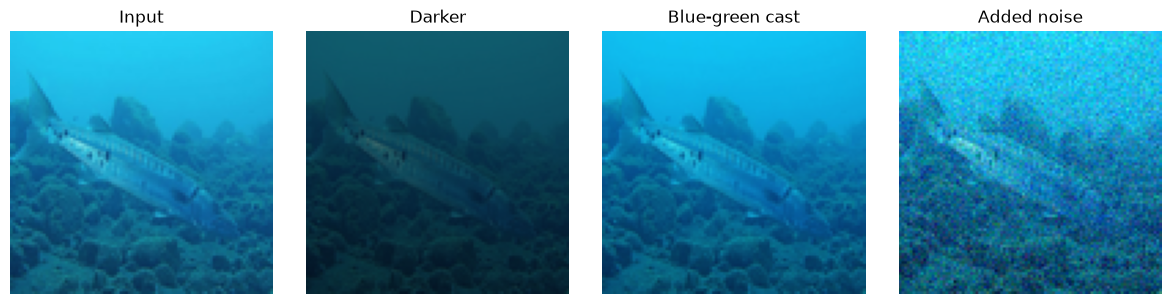

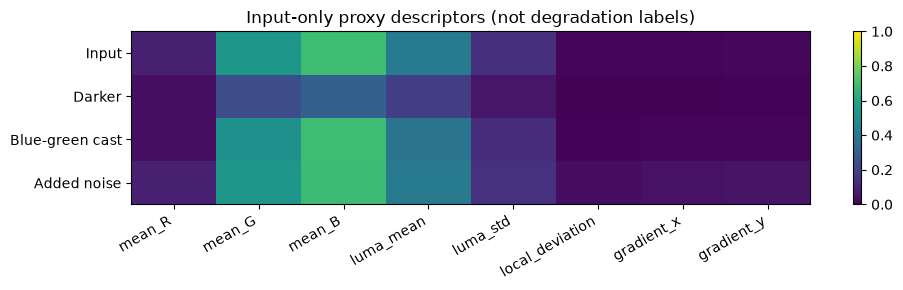

In [5]:
original = x_train[:1]
dark = original * 0.45
cast = original * original.new_tensor([0.45, 0.95, 1.0]).view(1, 3, 1, 1)
noisy = (original + 0.06 * torch.randn_like(original)).clamp(0, 1)
variants = torch.cat([original, dark, cast, noisy])
variant_names = ["Input", "Darker", "Blue-green cast", "Added noise"]
variant_z = degradation_descriptor(variants)
assert variant_z[1, 3] < variant_z[0, 3]

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, img, label in zip(axes, variants, variant_names):
    ax.imshow(img.permute(1, 2, 0).numpy()); ax.set_title(label); ax.axis("off")
plt.tight_layout(); plt.show(); plt.close(fig)
fig, ax = plt.subplots(figsize=(10, 3))
heatmap = ax.imshow(variant_z.numpy(), aspect="auto", vmin=0, vmax=1, cmap="viridis")
ax.set_xticks(range(8), FEATURE_NAMES, rotation=30, ha="right")
ax.set_yticks(range(4), variant_names)
ax.set_title("Input-only proxy descriptors (not degradation labels)")
fig.colorbar(heatmap, ax=ax); plt.tight_layout(); plt.show(); plt.close(fig)

## 4. 动态融合控制器：从静态参数出发

直接随机生成融合系数可能破坏预训练模型。这里让小型 MLP 预测**有界增量**：

$$\alpha(I)=\alpha_0+0.25\tanh(u_1),\quad
\beta(I)=\beta_0+0.25\tanh(u_2),$$
$$\lambda(I)=\operatorname{clip}(\lambda_0+0.25\tanh(u_3),0,1).$$

将 MLP 最后一层初始化为零，使增量初始为零。这样关闭强度门控后，
新模型应数值复现原模型。$\alpha_0,\beta_0$ 不强制限制到 [0,1]，保留原模型值；
0.25 是教学超参数，不是证明过的最佳范围。若 $\lambda$ 落在裁剪区外，梯度可能饱和。

MLP 为 8→16→4，共 212 个参数。第 4 个输出留给下一节的强度控制。

In [6]:
class DegradationController(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(8, 16)
        self.head = nn.Linear(16, 4)
        nn.init.zeros_(self.head.weight)
        nn.init.zeros_(self.head.bias)

    def forward(self, descriptor):
        return self.head(F.silu(self.hidden(descriptor)))

controller = DegradationController()
print("控制器参数数:", sum(p.numel() for p in controller.parameters()))
assert torch.count_nonzero(controller(z)) == 0

控制器参数数: 212


## 5. 加入增强强度门控

$$s(I)=\sigma(4+u_4),\qquad J=(1-s(I))I+s(I)E(I).$$

初始 $s\approx0.982$，接近增强分支，但**不完全等于原模型**。我们用显式开关关闭门控来做
原模型一致性检查。训练时，参考图作为输入还会构成保持样本 $(Y,Y)$，约束不必要改动。

冻结主干参数不意味着把主干计算包在 `no_grad()` 中：训练仍需通过输出卷积反传到控制器。
这里仅将主干参数的 `requires_grad` 设为 False；主干一直处于 eval 模式。

In [7]:
class TeachingEnhancer(nn.Module):
    def __init__(self, pretrained):
        super().__init__()
        self.backbone = copy.deepcopy(pretrained)
        for parameter in self.backbone.parameters():
            parameter.requires_grad_(False)
        self.controller = DegradationController()

    def forward(self, images, use_dynamic=True, use_strength=True):
        self.backbone.eval()
        features = self.backbone.body(self.backbone.head(images))
        ac, spatial = attention_paths(self.backbone, features)
        controls = self.controller(degradation_descriptor(images))
        delta = 0.25 * torch.tanh(controls[:, :3])
        if not use_dynamic:
            delta = torch.zeros_like(delta)
        alpha = self.backbone.alpha + delta[:, 0]
        beta = self.backbone.beta + delta[:, 1]
        lam = (self.backbone.lam.clamp(0, 1) + delta[:, 2]).clamp(0, 1)
        expand = lambda value: value.view(-1, 1, 1, 1)
        attention = ((1 - expand(lam)) * (expand(alpha) * ac + expand(beta) * spatial)
                     + expand(lam) * ac * spatial)
        enhanced = self.backbone.tail(attention * features)
        strength = torch.sigmoid(4.0 + controls[:, 3])
        if not use_strength:
            strength = torch.ones_like(strength)
        output = (1 - expand(strength)) * images + expand(strength) * enhanced
        # 训练时不 clamp：避免范围外像素梯度被截断。显示及存图时再 clamp。
        return {"image": output, "alpha": alpha, "beta": beta,
                "lambda": lam, "strength": strength, "descriptor": degradation_descriptor(images)}

torch.manual_seed(SEED)
prototype = TeachingEnhancer(baseline).to(DEVICE)
print("总参数:", sum(p.numel() for p in prototype.parameters()),
      "可训练参数:", sum(p.numel() for p in prototype.parameters() if p.requires_grad))

总参数: 4446 可训练参数: 212


## 6. 在训练前验证设计

检查：①关闭门控时与官方输出一致；②输出形状正确且有限；③梯度能到控制器；
④冻结主干无梯度。零初始化最后一层意味着第一次反传时隐藏层梯度可能为零，
但输出层必须能学习；后续更新后隐藏层才逐步获得梯度。

In [8]:
with torch.no_grad():
    expected = baseline(x_train)
    actual = prototype(x_train, use_strength=False)["image"]
    initialization_error = (expected - actual).abs().max().item()
    torch.testing.assert_close(actual, expected, atol=1e-6, rtol=1e-5)
    for h, w in [(17, 25), (65, 97)]:
        probe = torch.rand(1, 3, h, w, device=DEVICE)
        probe_output = prototype(probe)["image"]
        assert probe_output.shape == probe.shape and torch.isfinite(probe_output).all()

prototype.zero_grad(set_to_none=True)
prediction = prototype(x_train)["image"]
F.l1_loss(prediction, y_train).backward()
head_gradient = prototype.controller.head.weight.grad
assert head_gradient is not None and torch.isfinite(head_gradient).all()
assert head_gradient.abs().sum() > 0
assert all(p.grad is None for p in prototype.backbone.parameters())
prototype.zero_grad(set_to_none=True)
print({"初始化最大误差": initialization_error,
       "输出层梯度范数": float(head_gradient.norm()), "检查": "通过"})

{'初始化最大误差': 2.384185791015625e-07, '输出层梯度范数': 0.01465421449393034, '检查': '通过'}


## 7. 一个小样本训练实验

训练损失分为三部分：

$$L=L_{pair}+0.2L_{identity}+0.1L_{range}.$$

- $L_{pair}=\lVert J(I)-Y\rVert_1$：增强输入应接近配对目标。
- $L_{identity}=\lVert J(Y)-Y\rVert_1$：参考图作为输入时，尽量保持原貌。
- $L_{range}=\operatorname{mean}[\max(-J,0)+\max(J-1,0)]$：软约束输出范围。

**门控退化解**：若只使用保持损失，模型可能倾向 $s=0$，始终输出输入。
因此同时查看配对误差、相对“不增强”的误差和门控数值。参数取值是教学选择，未调优。
下面每次执行都重建控制器和优化器，避免反复运行单元格造成隐藏训练状态。

In [9]:
torch.manual_seed(SEED)
model = TeachingEnhancer(baseline).to(DEVICE)
optimizer = torch.optim.Adam(model.controller.parameters(), lr=0.01)
history = []
model.train()
for step in range(TRAIN_STEPS):
    optimizer.zero_grad(set_to_none=True)
    result = model(x_train)
    clean_result = model(y_train)
    paired = F.l1_loss(result["image"], y_train)
    identity = F.l1_loss(clean_result["image"], y_train)
    range_loss = torch.stack([
        (F.relu(-p) + F.relu(p - 1)).mean()
        for p in [result["image"], clean_result["image"]]
    ]).mean()
    loss = paired + 0.2 * identity + 0.1 * range_loss
    assert torch.isfinite(loss)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.controller.parameters(), max_norm=1.0)
    optimizer.step()
    history.append({"step": step + 1, "total": loss.item(), "paired": paired.item(),
                    "identity": identity.item(), "strength": result["strength"].mean().item()})
model.eval()
assert any(torch.count_nonzero(p).item() for p in model.controller.head.parameters())
print("第一步（更新前）:", history[0])
print("最后一步（更新前）:", history[-1])

第一步（更新前）: {'step': 1, 'total': 0.054487232118844986, 'paired': 0.047001998871564865, 'identity': 0.03712490200996399, 'strength': 0.9820137619972229}
最后一步（更新前）: {'step': 20, 'total': 0.05037064477801323, 'paired': 0.04464410990476608, 'identity': 0.028498707339167595, 'strength': 0.9887863993644714}


### 7.1 观察训练过程

损失降低最多只能说明模型更适应这几个训练样本；不能说明对新水域有效。
注意观察强度是否趋于零、保持误差是否增大，以及不同损失是否相互冲突。

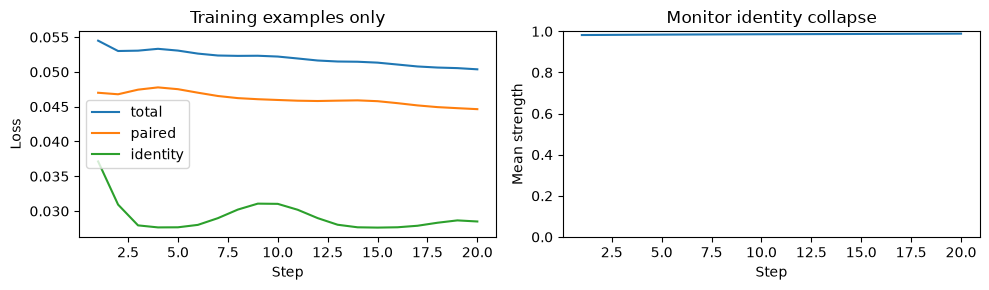

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for key in ["total", "paired", "identity"]:
    axes[0].plot([r["step"] for r in history], [r[key] for r in history], label=key)
axes[0].set(xlabel="Step", ylabel="Loss", title="Training examples only")
axes[0].legend()
axes[1].plot([r["step"] for r in history], [r["strength"] for r in history])
axes[1].set(xlabel="Step", ylabel="Mean strength", ylim=(0, 1), title="Monitor identity collapse")
plt.tight_layout(); plt.show(); plt.close(fig)

## 8. 看输出，也看控制参数

下面显示的是**同一训练样本**：输入、官方预训练结果、训练后的教学原型、参考图。
不挑选“最好看”的图片，不据此判断泛化。右侧参考只用于训练和对比，从未作为控制器输入。

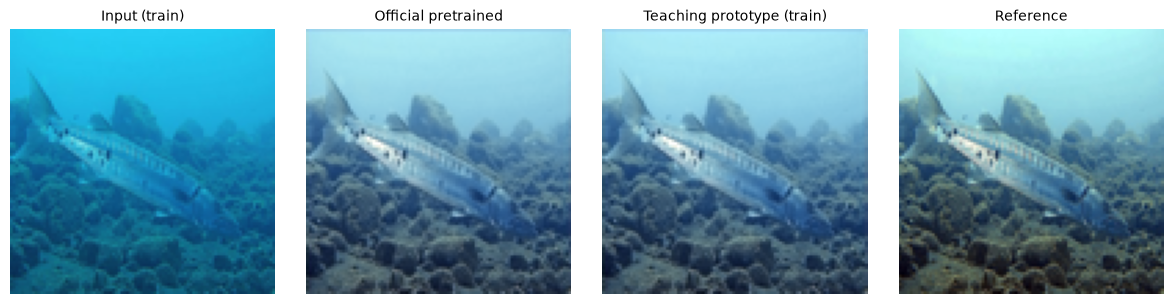

| 输入 | alpha | beta | lambda | strength |
|---|---:|---:|---:|---:|
| Input | 0.38481 | 0.68083 | 0.78570 | 0.98904 |
| Darker | 0.38684 | 0.67975 | 0.78442 | 0.98829 |
| Blue-green cast | 0.38860 | 0.68283 | 0.78301 | 0.98897 |
| Added noise | 0.38403 | 0.68022 | 0.78633 | 0.98902 |


同批训练样本 L1（输出先 clamp）： {'不增强': 0.141680508852005, '官方模型': 0.04577299579977989, '教学原型': 0.04407234862446785}


In [11]:
with torch.no_grad():
    pretrained_output = baseline(x_train)
    trained = model(x_train)
    variants_after = model(variants)
panels = [x_train[0], pretrained_output[0], trained["image"][0], y_train[0]]
titles = ["Input (train)", "Official pretrained", "Teaching prototype (train)", "Reference"]
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, panel, title in zip(axes, panels, titles):
    ax.imshow(panel.detach().clamp(0, 1).permute(1, 2, 0).cpu().numpy())
    ax.set_title(title, fontsize=10); ax.axis("off")
plt.tight_layout(); plt.show(); plt.close(fig)

table = "| 输入 | alpha | beta | lambda | strength |\n|---|---:|---:|---:|---:|\n"
for i, name in enumerate(variant_names):
    values = [float(variants_after[k][i]) for k in ["alpha", "beta", "lambda", "strength"]]
    table += "| " + name + " | " + " | ".join(f"{v:.5f}" for v in values) + " |\n"
display(Markdown(table))
print("同批训练样本 L1（输出先 clamp）：", {
    "不增强": F.l1_loss(x_train, y_train).item(),
    "官方模型": F.l1_loss(pretrained_output.clamp(0, 1), y_train).item(),
    "教学原型": F.l1_loss(trained["image"].clamp(0, 1), y_train).item()})

## 9. 消融：先理解开关，再做公平实验

下面是同一组训练后权重的**开关诊断**，用于理解各模块的行为。
训练后直接关掉模块会产生分布变化，不能替代“每个变体单独重新训练”的正式消融。

In [12]:
diagnostic = []
with torch.no_grad():
    for name, dynamic, strength in [
        ("Original coefficients, no strength", False, False),
        ("Dynamic fusion only", True, False),
        ("Strength only", False, True),
        ("Both controls", True, True),
    ]:
        out = model(x_train, use_dynamic=dynamic, use_strength=strength)["image"]
        diagnostic.append({"switch": name, "train_L1": F.l1_loss(out.clamp(0, 1), y_train).item()})
    torch.testing.assert_close(model(x_train, False, False)["image"], baseline(x_train), atol=1e-6, rtol=1e-5)
for row in diagnostic:
    print(row)

{'switch': 'Original coefficients, no strength', 'train_L1': 0.04577299579977989}
{'switch': 'Dynamic fusion only', 'train_L1': 0.043631404638290405}
{'switch': 'Strength only', 'train_L1': 0.04605376347899437}
{'switch': 'Both controls', 'train_L1': 0.04407234862446785}


### 正式实验应如何安排？

本次默认配置的执行观察：初始化与原模型的最大差异约为 2.38e-7；控制器输出层获得非零梯度。
20 步训练后的训练集 L1 约为 0.04407，官方输出为 0.04577。开关诊断中，仅动态融合的
L1 约为 0.04363，反而低于同时开启强度控制的结果。这说明**增加模块未必带来额外收益**；
不能因为设计更复杂就认为更好。这些值仅记录默认种子的教学运行，修改参数后应以新输出为准。

| 变体 | 单独训练内容 | 要验证的问题 |
|---|---|---|
| 原始 FGDPA | 同一数据协议下的基线 | 基准水平 |
| 全局特征动态控制 | 用主干全局池化替换退化描述，控制参数预算 | 收益是否仅来自增加容量？ |
| 退化描述动态融合 | 仅启用动态融合，重新训练 | 显式输入描述是否有效？ |
| 动态融合＋强度控制 | 两者共同训练 | 是否减少过度增强？ |
| 去除保持损失 | 其他条件不变重新训练 | 保持约束是否有贡献？ |

先固定 train/validation/test，所有统计和调参只使用 train/validation。核对作者 `uieb_test.txt`
与本地 `source_filename`，排除预训练重叠；无法排除时重新训练主干。至少运行多个随机种子，
报告均值与波动，并在未参与训练的数据集上评价。不同变体应统一冻结策略、训练步数和数据增强。
按亮度、偏色程度等输入属性分组时，阈值只用训练集确定。

报告 PSNR/SSIM、保持误差、参数量、同设备端到端延迟和失败案例。
不能因为只增加 212 个参数就推断耗时可忽略；描述提取会遍历整幅图像。

## 10. 学习检查与练习

1. **为什么不直接给 alpha、beta 随机赋值？** 先解释零增量初始化如何保护预训练结果，再尝试随机初始化对比。
2. **为什么第一次 hidden 层梯度可能为零？** 从最后一层权重初始化为零推导链式法则。
3. **为何不用参考图生成退化描述？** 这会造成训练/推理输入不一致和目标信息泄漏。
4. **如何判断保持门控塌缩？** 同时比较不增强误差、配对误差、保持误差与 strength，不能只看保持损失。
5. **只输入亮度是否足够？** 将其他描述置零，重新初始化并训练；之后再用正式验证集检验。
6. **为什么不能在冻结主干上随意加 no_grad？** 输出卷积仍需向前面的控制器传递梯度。
7. **什么结果会推翻设计？** 普通全局特征控制器达到同样收益，或者跨域效果下降、延迟显著增加。

建议练习顺序：先完成 1、2、4，再实现全局池化对照组，最后扩展为完整的数据加载与训练脚本。
教学实验展示了一个可训练设计；是否具有算法新颖性仍需专项文献查新。

In [13]:
# 最终检查：避免把运行成功等同于效果已验证。
assert len(history) == TRAIN_STEPS
assert torch.isfinite(trained["image"]).all()
assert all(torch.isfinite(torch.tensor(r["total"])) for r in history)
validation_summary = {
    "status": "教学单元顺序执行完成",
    "upstream_commit": UPSTREAM_COMMIT,
    "samples": [r["sample_id"] for r in train_rows],
    "steps": TRAIN_STEPS,
    "scope": "仅训练集小样本机制验证；未进行独立测试或正式消融",
    "baseline_equivalence": True,
    "gradient_path": True,
}
print(json.dumps(validation_summary, ensure_ascii=False, indent=2))

{
  "status": "教学单元顺序执行完成",
  "upstream_commit": "530c692feb99ecf6205bb929118a9167e2809d4d",
  "samples": [
    "sample_0001",
    "sample_0003",
    "sample_0004",
    "sample_0007"
  ],
  "steps": 20,
  "scope": "仅训练集小样本机制验证；未进行独立测试或正式消融",
  "baseline_equivalence": true,
  "gradient_path": true
}
